# **P**anatopic **A**dversarial **N**uclei **C**lassification **a**nd **K**nowledge-**E**nhanced **S**egmentation using Pathopix-GANs

### **Dataset Structure**
The dataset is organized into three folds: fold1, fold2, and fold3, consistent with the original dataset structure. Each fold contains data in a tabular format with the following four columns:

**image:** The RGB tile of the sample. <br>
**instances:** A list of nuclei instances. Each instance represents exactly one nucleus and is in binary format (1 - nucleus, 0 - background)<br>
**categories:** An integer class label for each nucleus, corresponding to one of the following categories:<br>

1. Neoplastic
2. Inflammatory
3. Connective
4. Dead
5. Epithelial

**tissue:** The integer tissue type from which the sample originates, belonging to one of these categories:

1. Adrenal Gland
2. Bile Duct
3. Bladder
4. Breast
5. Cervix
6. Colon
7. Esophagus
8. Head & Neck
9. Kidney
10. Liver
11. Lung
12. Ovarian
13. Pancreatic
14. Prostate
15. Skin
16. Stomach
17. Testis
18. Thyroid
19. Uterus




### **Libraries**

In [28]:
import pandas as pd
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import warnings
import ast
from collections import Counter
import seaborn as sns
import shutil
import glob
from tqdm import tqdm
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import random
import pickle

warnings.filterwarnings('ignore')

### **Sample Display**

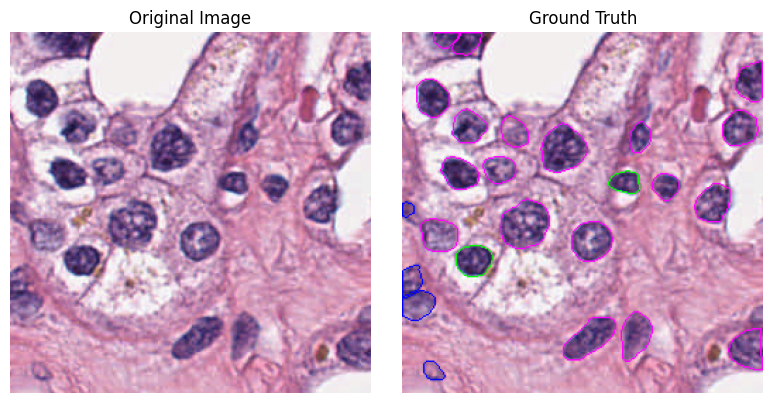

In [3]:
image_path = "../input/pannuke/dataset/fold_3/sample_2161/image.png"
mask_dir = "../input/pannuke/dataset/fold_3/sample_2161/masks"

category_colors = {
    "0": (255, 0, 0),    # Neoplastic - Red
    "1": (0, 255, 0),    # Inflammatory - Green
    "2": (0, 0, 255),    # Connective - Blue
    "3": (255, 255, 0),  # Dead - Yellow
    "4": (255, 0, 255)   # Epithelial - Magenta
}

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
overlay = image.copy()

mask_files = sorted(os.listdir(mask_dir))
for mask_file in mask_files:
    mask_path = os.path.join(mask_dir, mask_file)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    category = mask_file.split('/')[-1][5]
    color = category_colors.get(category, (255, 255, 255))
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, color, thickness=1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### **Initial Loading and Simple Preprocessing**

In [4]:
meta_data = pd.read_csv('../input/pannuke/dataset/metadata.csv')
meta_data['category'] = meta_data['category'].str.replace(" ", ",").apply(ast.literal_eval)
meta_data = meta_data.dropna(subset=['tissue'])

meta_data['fold'] = meta_data['file_path'].str[5]
meta_data['file_path'] = meta_data['file_path'].str[:-10]
meta_data.sample(5)

,file_path,category,tissue,fold
2138,fold_1/sample_2138,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]",7,1
7021,fold_3/sample_1842,[],5,3
3073,fold_2/sample_417,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,2
2132,fold_1/sample_2132,[],7,1
6748,fold_3/sample_1569,[],2,3


### **Data Distribution across Cells/Tissue**

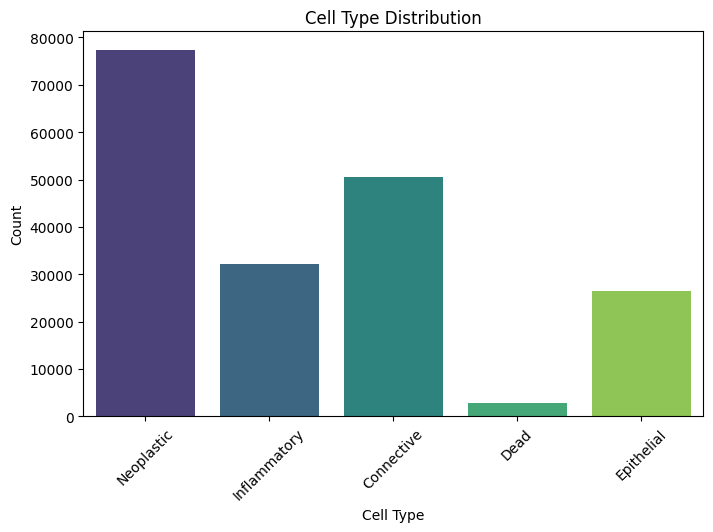

In [5]:
all_categories = [item for sublist in meta_data['category'] for item in sublist]
category_counts = Counter(all_categories)

category_names = ["Neoplastic", "Inflammatory", "Connective", "Dead", "Epithelial"]
category_values = [category_counts[i] for i in range(5)]

viridis_colors = sns.color_palette("viridis", len(category_names))

plt.figure(figsize=(8, 5))
sns.barplot(x=category_names, y=category_values, palette=viridis_colors)

plt.xlabel("Cell Type")
plt.ylabel("Count")
plt.title("Cell Type Distribution")
plt.xticks(rotation=45)

plt.show()

100%|██████████| 7901/7901 [00:00<00:00, 17821.30it/s]


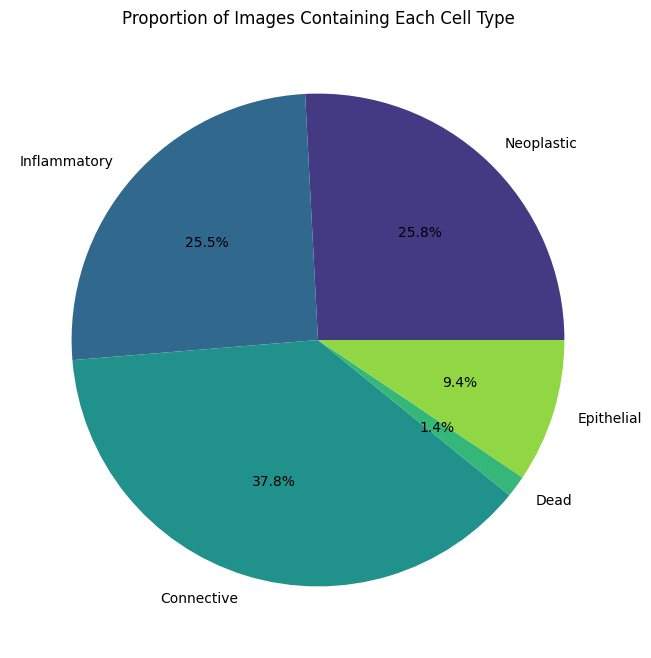

In [7]:
categories = {
    0: "Neoplastic",
    1: "Inflammatory",
    2: "Connective",
    3: "Dead",
    4: "Epithelial"
}

category_counts = {
    "Neoplastic": 0,
    "Inflammatory": 0,
    "Connective": 0,
    "Dead": 0,
    "Epithelial": 0
}

for _, row in tqdm(meta_data.iterrows(), total=len(meta_data)):
    category_list = row["category"]
    
    for cat, name in categories.items():
        if cat in category_list:
            category_counts[name] += 1

plt.figure(figsize=(8, 8))
plt.pie(category_counts.values(), labels=category_counts.keys(), autopct='%1.1f%%', colors=sns.color_palette("viridis", len(category_counts)))
plt.title("Proportion of Images Containing Each Cell Type")
plt.show()

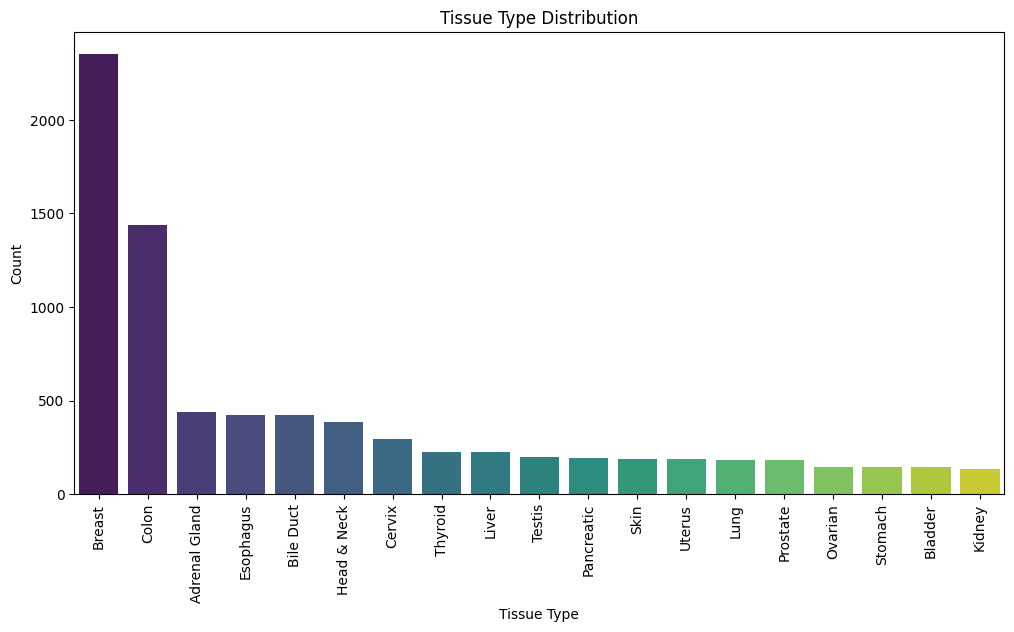

In [8]:
tissue_mapping = {
    0: "Adrenal Gland",
    1: "Bile Duct",
    2: "Bladder",
    3: "Breast",
    4: "Cervix",
    5: "Colon",
    6: "Esophagus",
    7: "Head & Neck",
    8: "Kidney",
    9: "Liver",
    10: "Lung",
    11: "Ovarian",
    12: "Pancreatic",
    13: "Prostate",
    14: "Skin",
    15: "Stomach",
    16: "Testis",
    17: "Thyroid",
    18: "Uterus"
}

meta_data['tissue_labels'] = meta_data['tissue'].astype(int).map(tissue_mapping)
plt.figure(figsize=(12, 6))

tissue_counts = meta_data['tissue_labels'].value_counts()

sns.barplot(x=tissue_counts.index, y=tissue_counts.values, palette="viridis")

plt.xlabel("Tissue Type")
plt.ylabel("Count")
plt.title("Tissue Type Distribution")
plt.xticks(rotation=90)

plt.show()

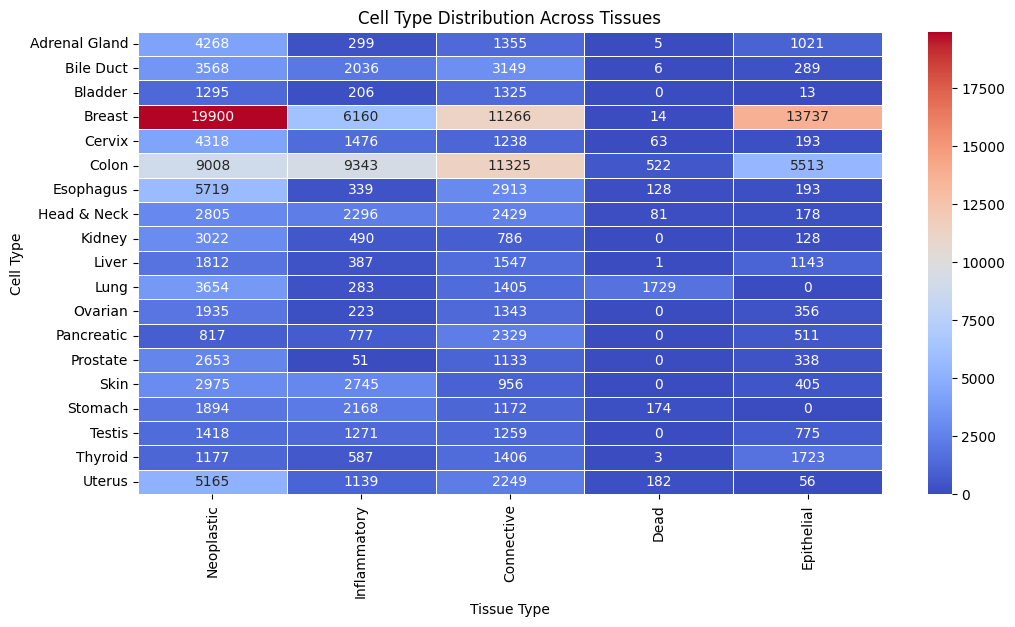

In [9]:
heatmap_data = pd.DataFrame(0, index=category_names, columns=tissue_mapping.values())

for _, row in meta_data.iterrows():
    tissue = row['tissue_labels']
    category_counts = Counter(row['category'])
    
    for cat_idx, cat_name in enumerate(category_names):
        heatmap_data.loc[cat_name, tissue] += category_counts.get(cat_idx, 0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data.T, cmap="coolwarm", annot=True, fmt="d", linewidths=0.5)

plt.xlabel("Tissue Type")
plt.ylabel("Cell Type")
plt.title("Cell Type Distribution Across Tissues")
plt.xticks(rotation=90)
plt.show()

### **Tissue Category Display**

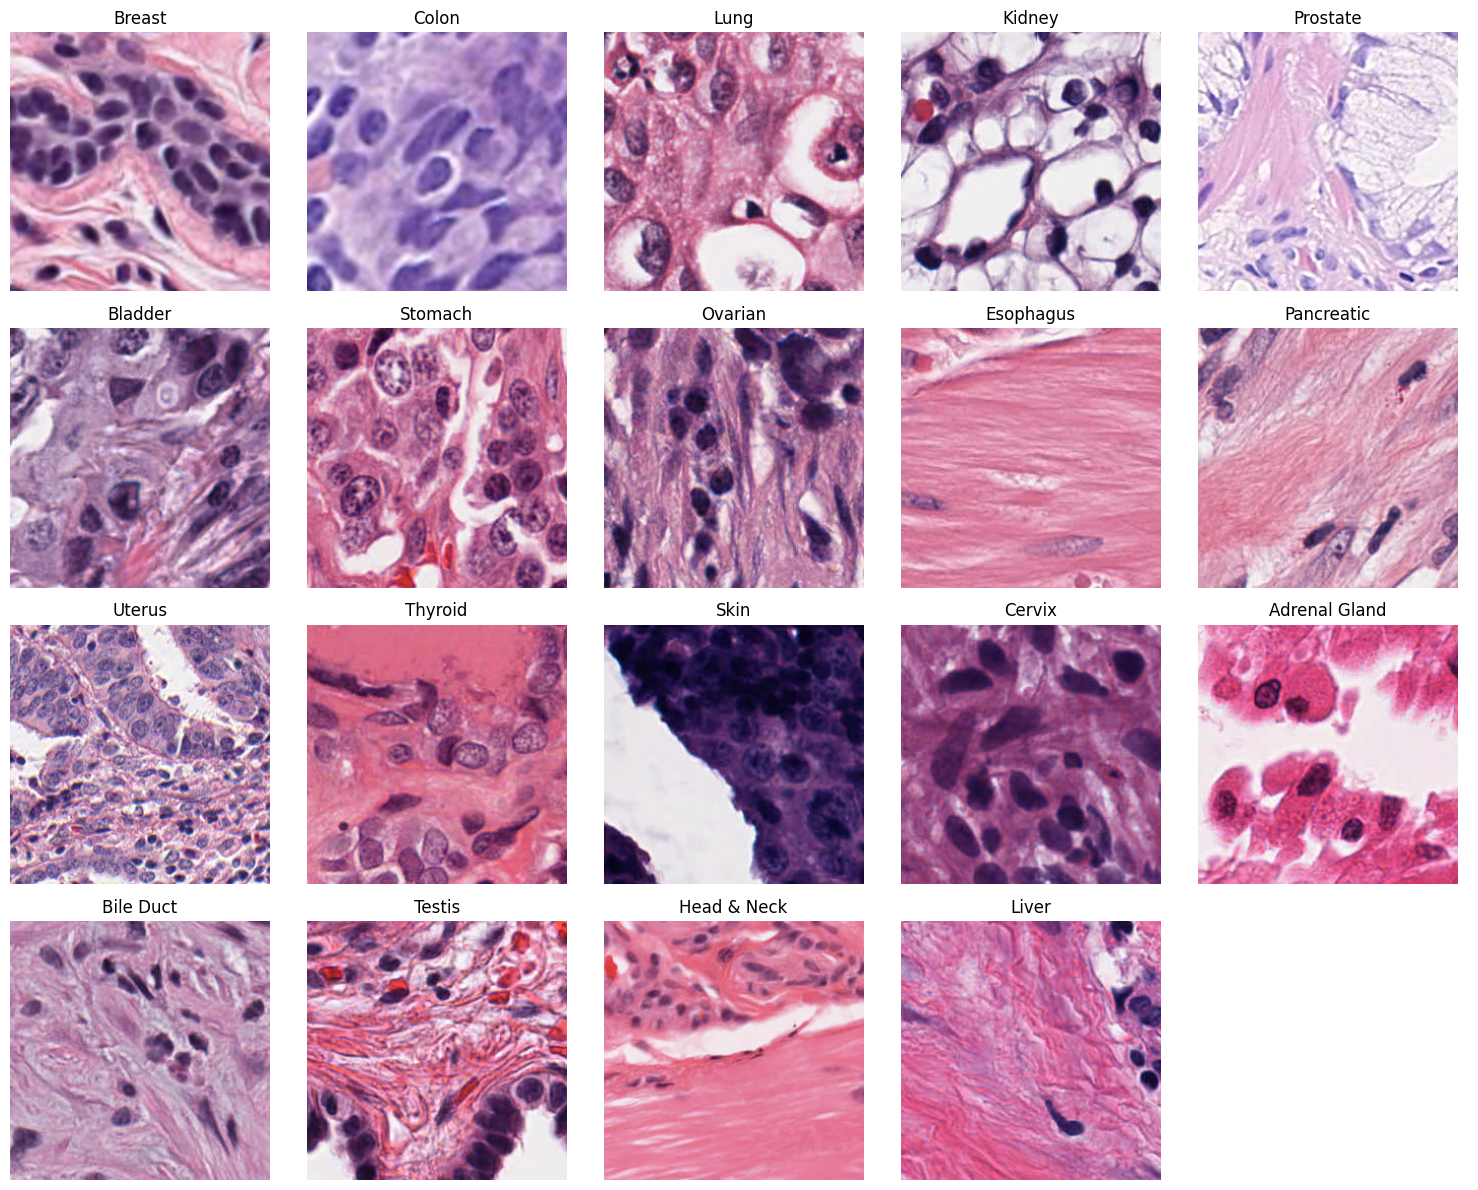

In [10]:
unique_tissues = meta_data['tissue_labels'].unique()

random_samples = {}
for tissue in unique_tissues:
    sample = meta_data[meta_data['tissue_labels'] == tissue].sample(1)
    random_samples[tissue] = sample['file_path'].values[0]

cols = 5
rows = int(np.ceil(len(unique_tissues) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))

axes = axes.flatten()

for i, (tissue, img_path) in enumerate(random_samples.items()):
    img = Image.open('../input/pannuke/dataset/' + img_path + '/image.png')
    axes[i].imshow(img)
    axes[i].set_title(tissue)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

#### **Extracting Category Cells from Each Category**

In [12]:
neoplastic_cells_df = meta_data[meta_data['category'].apply(lambda x: 0 in x)]
inflammatory_cells_df = meta_data[meta_data['category'].apply(lambda x: 1 in x)]
connective_cells_df = meta_data[meta_data['category'].apply(lambda x: 2 in x)]
dead_cells_df = meta_data[meta_data['category'].apply(lambda x: 3 in x)]
epithelial_cells_df = meta_data[meta_data['category'].apply(lambda x: 4 in x)]

neoplastic_cells_df.to_csv('neoplastic_cells_df.csv', index=False)
inflammatory_cells_df.to_csv('inflammatory_cells_df.csv', index=False)
connective_cells_df.to_csv('connective_cells_df.csv', index=False)
dead_cells_df.to_csv('dead_cells_df.csv', index=False)
epithelial_cells_df.to_csv('epithelial_cells_df.csv', index=False)

dead_cells_df.head()

,file_path,category,tissue,fold,tissue_labels
178,fold_1/sample_178,"[1, 2, 2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",3,1,Breast
776,fold_1/sample_776,"[1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 3, 3, 3, 3]",5,1,Colon
782,fold_1/sample_782,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",5,1,Colon
784,fold_1/sample_784,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5,1,Colon
790,fold_1/sample_790,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5,1,Colon


In [13]:
def load_images_and_merge_masks(dataset_path, df, category = 3):
    image_mask_dict = {}  

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing Samples"):
        sample_path = os.path.join(dataset_path, row["file_path"])

        image_path = os.path.join(sample_path, "image.png")
        if not os.path.exists(image_path):
            print(f"Image not found: {image_path}")
            continue
        image = cv2.imread(image_path)  

        mask_dir = os.path.join(sample_path, "masks")
        if not os.path.exists(mask_dir):
            print(f"Mask directory not found: {mask_dir}")
            continue

        merged_mask = None
        for mask_filename in os.listdir(mask_dir):
            if mask_filename.startswith(f"mask_{category}_"):  
                mask_path = os.path.join(mask_dir, mask_filename)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  

                if merged_mask is None:
                    merged_mask = mask  
                else:
                    merged_mask = cv2.bitwise_or(merged_mask, mask)  

        if merged_mask is not None:
            image_mask_dict[sample_path] = (image, merged_mask)  

    return image_mask_dict

In [26]:
DATASET_PATH = "../input/pannuke/dataset"

#dead_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, dead_cells_df, 3)
#neoplastic_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, neoplastic_cells_df, 0)
#inflammatory_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, inflammatory_cells_df, 1)
connective_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, connective_cells_df, 2)
epithelial_image_mask_dict = load_images_and_merge_masks(DATASET_PATH, epithelial_cells_df, 4)

Processing Samples: 100%|██████████| 1528/1528 [02:34<00:00,  9.88it/s]


In [30]:
if True:
    dictionaries = {
        "neoplastic_image_mask_dict.pkl": neoplastic_image_mask_dict,
        "inflammatory_image_mask_dict.pkl": inflammatory_image_mask_dict,
        "connective_image_mask_dict.pkl": connective_image_mask_dict,
        "dead_image_mask_dict.pkl": dead_image_mask_dict,
        "epithelial_image_mask_dict.pkl": epithelial_image_mask_dict,
    }
    
    for filename, data in tqdm(dictionaries.items()):
        with open(filename, "wb") as f:
            pickle.dump(data, f)

100%|██████████| 5/5 [00:27<00:00,  5.47s/it]


In [47]:
pickle_files = {
    "dead_image_mask_dict.pkl": "Dead Cells",
    "neoplastic_image_mask_dict.pkl": "Neoplastic Cells",
    "inflammatory_image_mask_dict.pkl": "Inflammatory Cells",
    "connective_image_mask_dict.pkl": "Connective Cells",
    "epithelial_image_mask_dict.pkl": "Epithelial Cells",
}

cell_types = {}

for filename, cell_type in tqdm(pickle_files.items(), desc="Loading Pickle Files"):
    with open(filename, "rb") as f:
        cell_types[cell_type] = pickle.load(f)

print("\nAll pickle files loaded successfully!")

Loading Pickle Files: 100%|██████████| 5/5 [00:03<00:00,  1.43it/s]


All pickle files loaded successfully!


### **Understanding Mean Intensity Distribution**

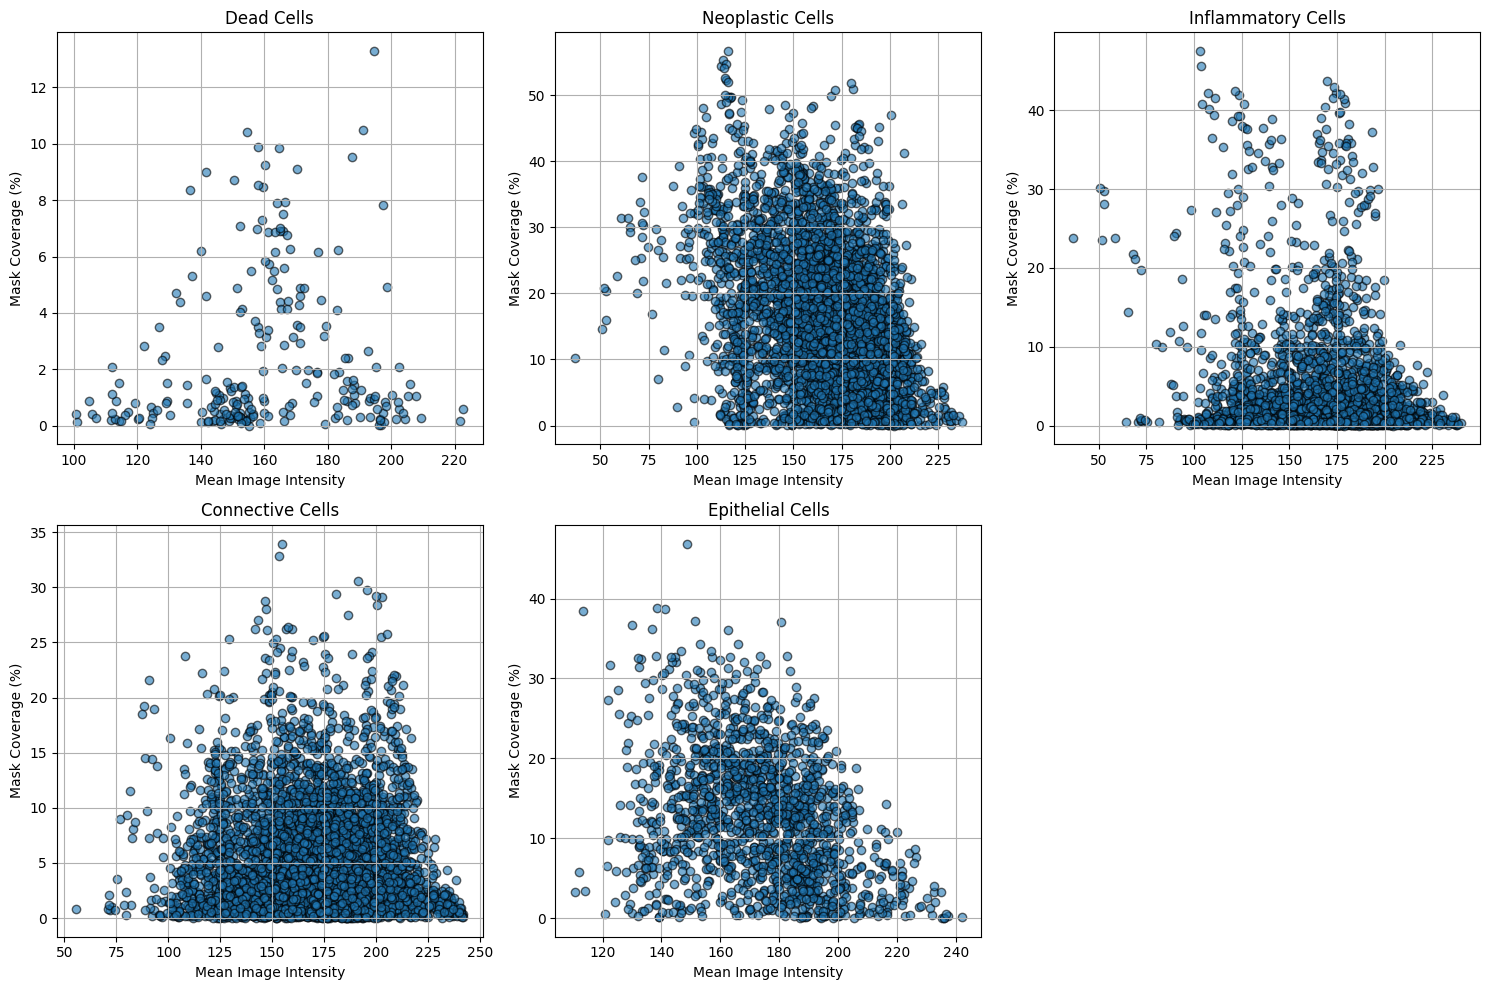

In [53]:
plt.figure(figsize=(15, 10))

for i, (cell_type, image_mask_dict) in enumerate(cell_types.items(), 1):
    mean_intensities = []
    mask_coverages = []

    for image_path, (image, mask) in image_mask_dict.items():
        mean_intensity = np.mean(image)
        mask_coverage = np.count_nonzero(mask) / mask.size * 100

        mean_intensities.append(mean_intensity)
        mask_coverages.append(mask_coverage)

    plt.subplot(2, 3, i)
    plt.scatter(mean_intensities, mask_coverages, alpha=0.6, edgecolors="black")
    plt.xlabel("Mean Image Intensity")
    plt.ylabel("Mask Coverage (%)")
    plt.title(f"{cell_type}")
    plt.grid(True)

plt.tight_layout()
plt.show()

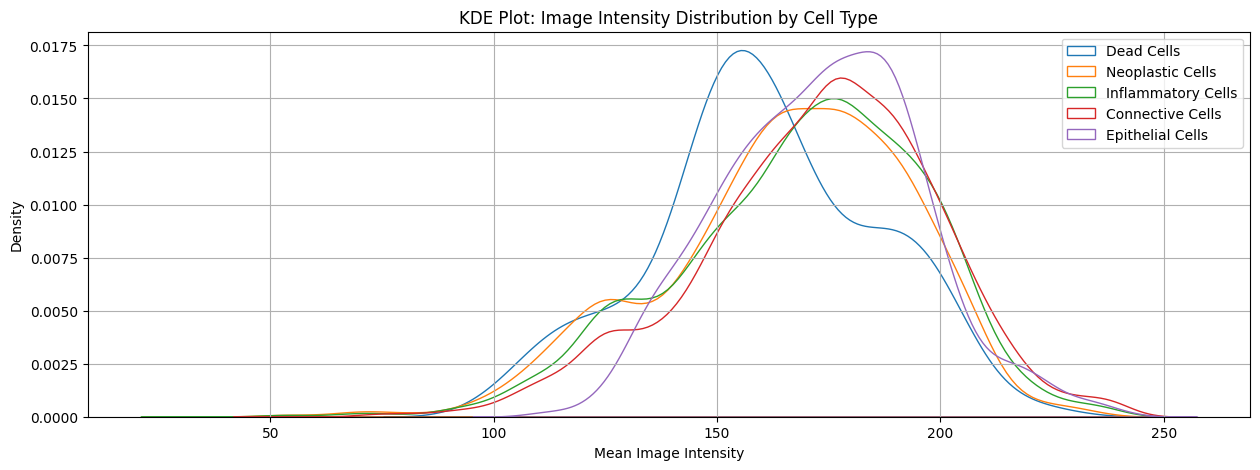

In [57]:
intensities = []
cell_labels = []

plt.figure(figsize=(15, 5))

for cell_type, image_mask_dict in cell_types.items():
    type_intensities = []

    for image_path, (image, mask) in image_mask_dict.items():
        mean_intensity = np.mean(image)
        type_intensities.append(mean_intensity)
        intensities.append(mean_intensity)
        cell_labels.append(cell_type)

    sns.kdeplot(type_intensities, fill=True, label=cell_type, alpha=0.0)

plt.xlabel("Mean Image Intensity")
plt.ylabel("Density")
plt.title("KDE Plot: Image Intensity Distribution by Cell Type")
plt.legend()
plt.grid(True)
plt.show()

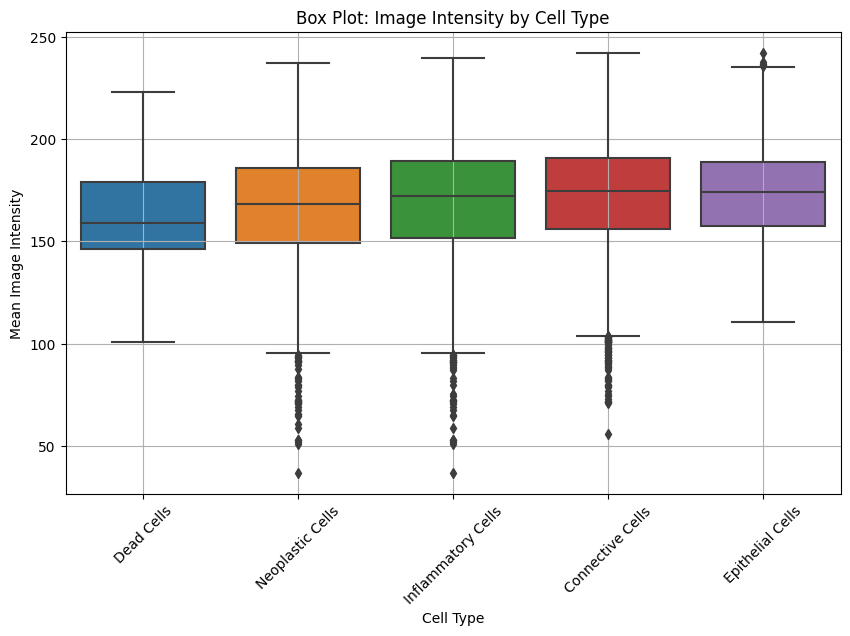

In [58]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=cell_labels, y=intensities)
plt.xlabel("Cell Type")
plt.ylabel("Mean Image Intensity")
plt.title("Box Plot: Image Intensity by Cell Type")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()